# Sklearn Multilabel Baselines

Notebook 02 trained **independent** XGBoost classifiers per label (Binary Relevance).  
This notebook explores sklearn's built-in multilabel strategies that **capture label dependencies**.

| Method | Label dependencies? | Model family | Key idea |
|--------|-------------------|--------------|----------|
| `OneVsRestClassifier(LogisticRegression)` | No | Linear | Simplest possible baseline |
| `ClassifierChain(LogisticRegression)` | **Yes** | Linear | Each label sees prior label predictions as features |
| `ClassifierChain(RandomForest)` | **Yes** | Tree ensemble | Nonlinear + label chaining |
| `MLPClassifier` (native multilabel) | **Implicit** | Neural net | Shared hidden layers, sigmoid outputs |

In [12]:
import numpy as np
import pandas as pd
import pickle
import time
from pathlib import Path

from sklearn.multioutput import ClassifierChain
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    average_precision_score, hamming_loss,
    precision_recall_curve, classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120

%matplotlib inline

import warnings
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)


In [13]:
# ── Feature Toggle ──────────────────────────────────────────────────
# Set to True to EXCLUDE p(secondary | primary) features and
# total_cascade_probability. This lets you compare feature importance
# with and without these engineered conditional-probability features.
EXCLUDE_CASCADE_PROB_FEATURES = True

## 1. Load Data

In [14]:
# ── Load data exactly as in the XGBoost notebook (02) ──
DATA_DIR = Path('../data/chronological_prepared_data')

X_train = np.load(DATA_DIR / 'X_train.npy')
X_test  = np.load(DATA_DIR / 'X_test.npy')
y_train = np.load(DATA_DIR / 'y_train.npy')
y_test  = np.load(DATA_DIR / 'y_test.npy')

with open(DATA_DIR / 'metadata.pkl', 'rb') as f:
    metadata = pickle.load(f)

feature_names = metadata['feature_names']
target_names  = metadata['target_names']

# ── Optionally remove cascade-probability features ──────────────────
if EXCLUDE_CASCADE_PROB_FEATURES:
    _keep_mask = []
    _removed = []
    for _i, _name in enumerate(feature_names):
        if (_name.startswith('p_') and _name.endswith('_given_primary')) or _name == 'total_cascade_probability':
            _removed.append(_name)
            _keep_mask.append(False)
        else:
            _keep_mask.append(True)
    _keep_mask = np.array(_keep_mask)
    X_train = X_train[:, _keep_mask]
    X_test  = X_test[:, _keep_mask]
    feature_names = [n for n, k in zip(feature_names, _keep_mask) if k]
    print(f"\n⚠ Excluded {len(_removed)} cascade-probability features:")
    for _r in _removed:
        print(f"  - {_r}")
    print(f"Remaining features: {len(feature_names)}")

print(f'Train : {X_train.shape[0]:,} samples, {X_train.shape[1]} features')
print(f'Test  : {X_test.shape[0]:,}  samples')
print(f'Labels: {len(target_names)}')
print(f'Split : {metadata.get("split_type", "unknown")}')

# ── Chronological validation split (same as XGBoost notebook) ──
val_size  = 0.1
split_idx = int(len(X_train) * (1 - val_size))

X_tr  = X_train[:split_idx]
y_tr  = y_train[:split_idx]
X_val = X_train[split_idx:]
y_val = y_train[split_idx:]

# ── Negative subsampling (same strategy as XGBoost notebook) ──
# Keep all rows positive for ANY label, subsample pure-negatives
NEG_SUBSAMPLE_RATIO = 5  # same as XGBoost

any_pos_mask = y_tr.sum(axis=1) > 0
pos_idx = np.where(any_pos_mask)[0]
neg_idx = np.where(~any_pos_mask)[0]
n_neg_keep = min(len(neg_idx), NEG_SUBSAMPLE_RATIO * len(pos_idx))
rng = np.random.RandomState(42)
neg_keep = rng.choice(neg_idx, size=int(n_neg_keep), replace=False)
keep_idx = np.sort(np.concatenate([pos_idx, neg_keep]))

X_train = X_tr[keep_idx]
y_train = y_tr[keep_idx]

print(f'\nNegative subsampling: {len(pos_idx):,} pos-any + {int(n_neg_keep):,} neg '
      f'(ratio={NEG_SUBSAMPLE_RATIO}) = {len(keep_idx):,} total')

print(f'\nPositive prevalence per label:')
for i, name in enumerate(target_names):
    cnt = int(y_train[:, i].sum())
    pct = cnt / len(y_train) * 100
    print(f'    {name:30s} {cnt:6,d}  ({pct:5.2f}%)')

print(f'\nTraining   : {X_train.shape[0]:,}  (neg-subsampled)')
print(f'Validation : {X_val.shape[0]:,}  (tail-end of train period)')
print(f'Test       : {X_test.shape[0]:,}  (most recent events)')
print(f'Features   : {X_train.shape[1]}')
print(f'Labels     : {len(target_names)}')
print(f'\nTimeline:  [--- Train ---][-- Val --][---- Test ----]')
print(f'           No data leakage: val & test are strictly after train.')


⚠ Excluded 30 cascade-probability features:
  - p_Avalanche_given_primary
  - p_Blizzard_given_primary
  - p_Coastal_Flood_given_primary
  - p_Cold_Wind_Chill_given_primary
  - p_Debris_Flow_given_primary
  - p_Dense_Fog_given_primary
  - p_Dust_Storm_given_primary
  - p_Excessive_Heat_given_primary
  - p_Extreme_Cold_Wind_Chill_given_primary
  - p_Flash_Flood_given_primary
  - p_Flood_given_primary
  - p_Frost_Freeze_given_primary
  - p_Hail_given_primary
  - p_Heat_given_primary
  - p_Heavy_Rain_given_primary
  - p_Heavy_Snow_given_primary
  - p_High_Surf_given_primary
  - p_High_Wind_given_primary
  - p_Ice_Storm_given_primary
  - p_Lightning_given_primary
  - p_Marine_Hail_given_primary
  - p_Marine_Thunderstorm_Wind_given_primary
  - p_Rip_Current_given_primary
  - p_Storm_Surge_Tide_given_primary
  - p_Thunderstorm_Wind_given_primary
  - p_Tornado_given_primary
  - p_Waterspout_given_primary
  - p_Wildfire_given_primary
  - p_Winter_Weather_given_primary
  - total_cascade_probab

In [15]:
# Standardise features (important for LogReg and MLP, harmless for RF)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

# Handle zero-variance features (NaN/Inf after scaling)
X_train_s = np.nan_to_num(X_train_s, nan=0.0, posinf=0.0, neginf=0.0)
X_val_s   = np.nan_to_num(X_val_s,   nan=0.0, posinf=0.0, neginf=0.0)
X_test_s  = np.nan_to_num(X_test_s,  nan=0.0, posinf=0.0, neginf=0.0)

n_const = (scaler.var_ == 0).sum()
print('Scaled — mean ~0, std ~1')
print(f'  Train mean range: [{X_train_s.mean(axis=0).min():.3f}, {X_train_s.mean(axis=0).max():.3f}]')
print(f'  Train std  range: [{X_train_s.std(axis=0).min():.3f}, {X_train_s.std(axis=0).max():.3f}]')
if n_const > 0:
    print(f'  ⚠ {n_const} zero-variance feature(s) set to 0 after scaling')

# Determine label order by prevalence (most common first) for Classifier Chains
label_order = np.argsort(y_train.sum(axis=0))[::-1]
print(f'\nLabel order for chains (indices): {label_order.tolist()}')
print(f'Top label: {target_names[label_order[0]]}')


Scaled — mean ~0, std ~1
  Train mean range: [-0.000, 0.000]
  Train std  range: [1.000, 1.000]

Label order for chains (indices): [12, 7, 5, 6, 13, 10, 3, 4, 8, 9, 14, 2, 0, 15, 1, 11]
Top label: Thunderstorm Wind


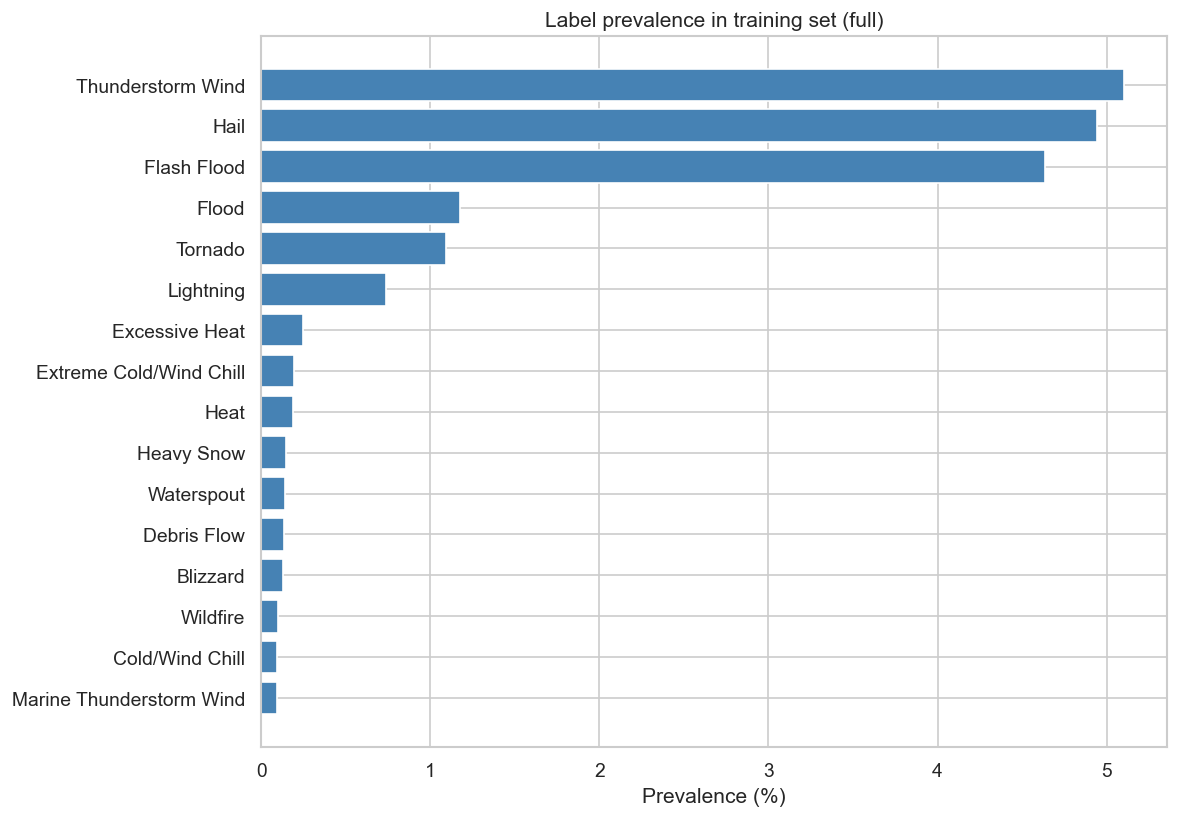

In [16]:
# Quick look at label prevalence
prevalence = y_train.mean(axis=0)
prev_df = pd.DataFrame({'label': target_names, 'train_prev': prevalence}).sort_values('train_prev', ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(prev_df['label'], prev_df['train_prev'] * 100, color='steelblue')
ax.set_xlabel('Prevalence (%)')
ax.set_title('Label prevalence in training set (full)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 2. Shared Evaluation Helpers

In [17]:
def evaluate(name, y_true, y_pred, y_prob=None):
    """Compute standard multilabel metrics and return a summary dict."""
    res = {
        'model': name,
        'f1_macro':      f1_score(y_true, y_pred, average='macro',    zero_division=0),
        'f1_micro':      f1_score(y_true, y_pred, average='micro',    zero_division=0),
        'f1_weighted':   f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'precision_weighted': precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'recall_weighted':    recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'precision_macro': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'recall_macro':    recall_score(y_true, y_pred, average='macro',    zero_division=0),
        'hamming_loss':    hamming_loss(y_true, y_pred),
        'subset_accuracy': (y_true == y_pred).all(axis=1).mean(),
    }
    if y_prob is not None:
        res['aucpr_weighted'] = average_precision_score(y_true, y_prob, average='weighted')
    print(f'--- {name} ---')
    print(f"  F1 (w/m/M): {res['f1_weighted']:.4f} / {res['f1_micro']:.4f} / {res['f1_macro']:.4f}")
    if 'aucpr_weighted' in res:
        print(f"  AUCPR (w):  {res['aucpr_weighted']:.4f}")
    return res


def per_label_f1(y_true, y_pred, target_names):
    """Return a DataFrame of per-label F1/precision/recall."""
    rows = []
    for i, lbl in enumerate(target_names):
        sup = int(y_true[:, i].sum())
        rows.append({
            'label': lbl,
            'support': sup,
            'f1':        f1_score(y_true[:, i], y_pred[:, i], zero_division=0),
            'precision': precision_score(y_true[:, i], y_pred[:, i], zero_division=0),
            'recall':    recall_score(y_true[:, i], y_pred[:, i], zero_division=0),
        })
    return pd.DataFrame(rows)


# We'll collect all results here
all_results = []
all_preds   = {}  # name -> y_pred


## 3. Train & Evaluate Each Method

Each method gets its own tuning + training block.
Uses `class_weight='balanced'` throughout to handle imbalance.

In [18]:
# ── Modular Model Save/Load Setup ──────────────────────────────────
if EXCLUDE_CASCADE_PROB_FEATURES:
    MODEL_DIR = Path('../models/baseline/sklearn_models_no_cascade_prob')
else:
    MODEL_DIR = Path('../models/baseline/sklearn_models')
MODEL_DIR.mkdir(parents=True, exist_ok=True)

all_results = []
all_preds = {}
trained_methods = set()

def save_method_checkpoint(method_id, **kwargs):
    """Save results for a specific method to a dedicated checkpoint file."""
    ckpt_path = MODEL_DIR / f"{method_id}_checkpoint.pkl"
    # Merge with existing global results if they exist for this method
    # Actually, we just save what's passed.
    with open(ckpt_path, 'wb') as f:
        pickle.dump(kwargs, f)
    print(f'\n✅ Saved {method_id} checkpoint to {ckpt_path}')

# Load any existing modular checkpoints
for ckpt_file in sorted(MODEL_DIR.glob('*_checkpoint.pkl')):
    if ckpt_file.name == '_checkpoint.pkl': continue # skip old monolithic if it exists
    method_id = ckpt_file.name.replace('_checkpoint.pkl', '')
    with open(ckpt_file, 'rb') as f:
        data = pickle.load(f)
    
    # Restore variables to global scope
    for k, v in data.items():
        globals()[k] = v
        if k == 'res':
            all_results.append(v)
        if k == 'y_pred':
            # We need to know which method this pred belongs to
            # The calling code sets 'y_pred' in kwargs
            # We'll use method names from the results 'model' field
            pass
    
    # Special handling for all_preds based on results names
    if 'res' in data:
        model_name = data['res']['model']
        if 'y_pred' in data:
            all_preds[model_name] = data['y_pred']
        elif 'y_pred_mlp' in data: # backward compat or specific names
             all_preds[model_name] = data['y_pred_mlp']
        # add more mappings if needed
             
    trained_methods.add(method_id)

if trained_methods:
    print(f'Found {len(trained_methods)} modular checkpoints: {", ".join(sorted(trained_methods))}')
else:
    print('No modular checkpoints found — training from scratch.')


Found 1 modular checkpoints: ovr_lr


In [19]:
from itertools import product as iter_product

def val_macro_aucpr(model, X_tr, y_tr, X_v, y_v):
    """Train model, predict on val, return macro AUCPR."""
    model.fit(X_tr, y_tr)
    y_prob = model.predict_proba(X_v)
    return average_precision_score(y_v, y_prob, average='weighted')

### Method 1 — OneVsRest Logistic Regression

Simplest possible baseline. Each label is an independent binary classifier.
Uses `class_weight='balanced'`.

In [20]:
method_id = 'ovr_lr'
if method_id not in trained_methods:
    print('=' * 60)
    print('Method 1: OneVsRest(LogisticRegression)')
    print('=' * 60)
    if method_id not in trained_methods:
        t0_total = time.time()
        
        # ── HP grid: C values only (lbfgs + L2 — fastest convergence) ──
        C_values = [0.01, 0.1, 1.0, 10.0]
        best_ovr_score, best_C = -1, 1.0
        
        print(f'Searching {len(C_values)} C values (lbfgs/L2) ...\n')
        
        for i, C in enumerate(C_values):
            t0 = time.time()
            model = OneVsRestClassifier(
                LogisticRegression(verbose=0, 
                    class_weight='balanced', max_iter=1000, solver='lbfgs',
                    C=C, penalty='l2', random_state=42),
                n_jobs=1
            )
            score = val_macro_aucpr(model, X_train_s, y_train, X_val_s, y_val)
        
            marker = ''
            if score > best_ovr_score:
                best_ovr_score = score
                best_C = C
                marker = ' ← best'
        
            # print HP search detail
                pass
        
        print(f'\n  ✓ Best: C={best_C}, val AUCPR={best_ovr_score:.4f}')
        
        # ── Train final model ──
        print(f'\nTraining final OVR-LogReg with C={best_C} ...')
        ovr_lr = OneVsRestClassifier(
            LogisticRegression(verbose=0, 
                class_weight='balanced', max_iter=2000, solver='lbfgs',
                C=best_C, penalty='l2', random_state=42),
            n_jobs=1
        )
        ovr_lr.fit(X_train_s, y_train)
        
        y_pred_ovr     = ovr_lr.predict(X_test_s)
        y_prob_ovr     = ovr_lr.predict_proba(X_test_s)
        y_prob_ovr_val = ovr_lr.predict_proba(X_val_s)
        
        elapsed = time.time() - t0_total
        print(f'\nTotal time (tune + train): {elapsed:.1f}s\n')
        res = evaluate('OVR-LogReg', y_test, y_pred_ovr, y_prob_ovr)
        best_penalty = 'l2'
        best_l1_ratio = None
        save_method_checkpoint(method_id, res=res, y_pred_ovr=y_pred_ovr, ovr_lr=ovr_lr, y_prob_ovr=y_prob_ovr, y_prob_ovr_val=y_prob_ovr_val, best_C=best_C, best_penalty=best_penalty, best_l1_ratio=best_l1_ratio)
else:
    print(f"Method '{method_id}' already trained. Skipping training and loading from checkpoint.")
    ckpt_path = MODEL_DIR / f"{method_id}_checkpoint.pkl"
    with open(ckpt_path, 'rb') as f:
        data = pickle.load(f)
    res = data['res']
    y_pred_ovr = data.get('y_pred_ovr', data.get('y_pred'))
    y_prob_ovr = data.get('y_prob_ovr', data.get('y_prob'))


Method 'ovr_lr' already trained. Skipping training and loading from checkpoint.


/var/folders/md/l911vh8d02j9khvbpjpxvb4r0000gn/T/ipykernel_43872/1345450358.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_f1, x='f1', y='label', palette='viridis')


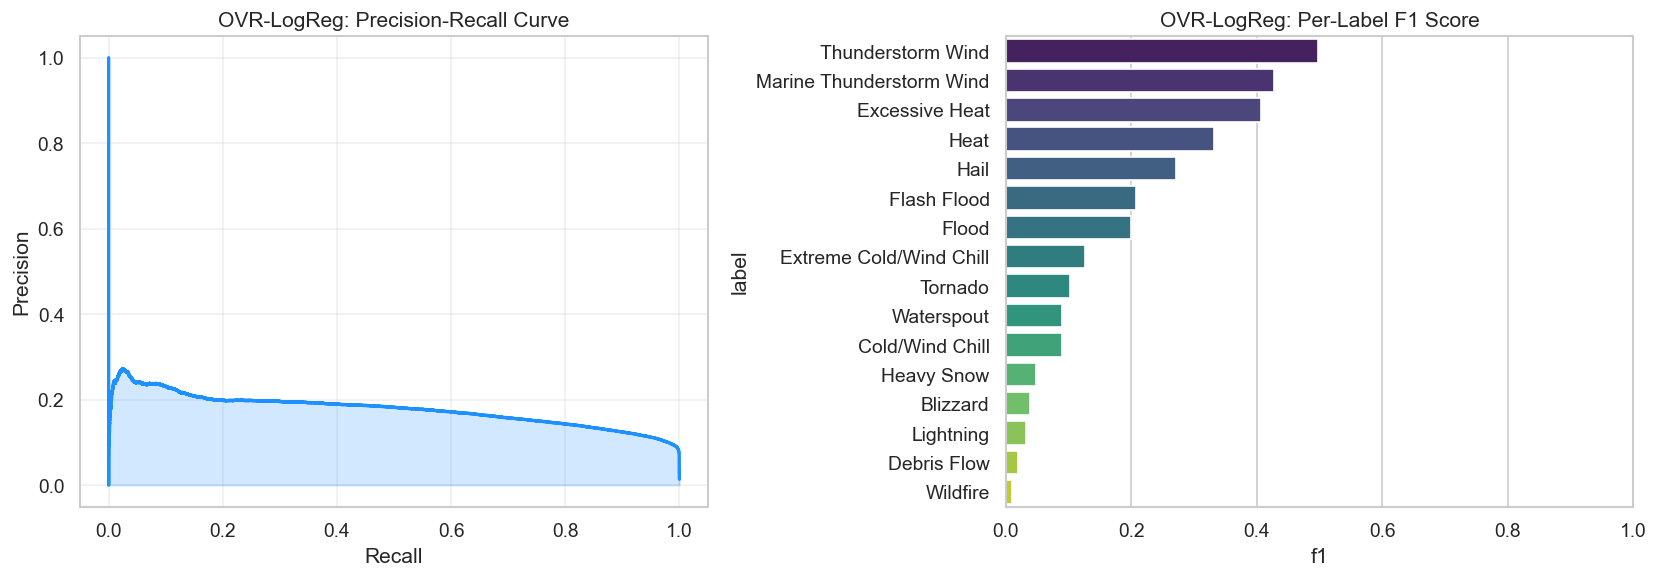

In [21]:

# --- Diagnostic Visualizations ---
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(14, 5))

# 1. Precision-Recall Curve (Weighted)
plt.subplot(1, 2, 1)
precision, recall, _ = precision_recall_curve(y_test.ravel(), y_prob_ovr.ravel())
plt.plot(recall, precision, color='dodgerblue', lw=2)
plt.fill_between(recall, precision, alpha=0.2, color='dodgerblue')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'{res["model"]}: Precision-Recall Curve')
plt.grid(True, alpha=0.3)

# 2. Per-Label F1 Score
plt.subplot(1, 2, 2)
df_f1 = per_label_f1(y_test, y_pred_ovr, target_names).sort_values('f1', ascending=False)
sns.barplot(data=df_f1, x='f1', y='label', palette='viridis')
plt.title(f'{res["model"]}: Per-Label F1 Score')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

**Model Insights: OneVsRest (Logistic Regression)**

The OVR baseline treats each disaster type independently. The per-label F1 plot reveals which disasters are easiest to predict in isolation (often those with higher prevalence or distinct feature signals) and where the features lack sufficient discriminative power. The PR curve provides a global view of the trade-off between capturing as many events as possible (recall) versus avoiding false alarms (precision).

### Method 2 — Classifier Chain (Logistic Regression)

Labels are ordered in a chain; each classifier sees prior label predictions as features.
Uses the same best `C` from OVR tuning.

In [23]:
method_id = 'chain_lr_ecc'
if method_id not in trained_methods:
    print('=' * 60)
    print('Method 2: ClassifierChain(LogisticRegression) - ECC Ensemble')
    print('=' * 60)
    if method_id not in trained_methods:
        t0_total = time.time()
        
        # Uses same best_C from OVR tuning — ensemble of 3 random chain orderings
        chains_lr = []
        for seed in [0, 1, 2]:
            # Use prevalence order for seed 0, random for others
            curr_order = label_order if seed == 0 else 'random'
            chain = ClassifierChain(
                LogisticRegression(
                    class_weight='balanced', max_iter=2000, solver='lbfgs',
                    C=best_C, penalty=best_penalty,
                    **({'l1_ratio': best_l1_ratio} if best_l1_ratio else {}),
                    random_state=42),
                order=curr_order, random_state=seed
            )
            chain.fit(X_train_s, y_train)
            chains_lr.append(chain)
            print(f'  Chain {seed} done — order: {chain.order_[:5]}...')
        
        # Ensemble: average predicted probabilities, then threshold
        y_prob_chain_lr     = np.mean([c.predict_proba(X_test_s) for c in chains_lr], axis=0)
        y_prob_chain_lr_val = np.mean([c.predict_proba(X_val_s)  for c in chains_lr], axis=0)
        y_pred_chain_lr     = (y_prob_chain_lr >= 0.5).astype(int)
        
        elapsed = time.time() - t0_total
        print(f'\nTotal time: {elapsed:.1f}s\n')
        res = evaluate('Chain-LogReg (ECC x3)', y_test, y_pred_chain_lr, y_prob_chain_lr)
        all_preds['Chain-LogReg (ECC x3)'] = y_pred_chain_lr
    
    save_method_checkpoint(method_id, res=res, y_pred_chain_lr=y_pred_chain_lr, chains_lr=chains_lr, y_prob_chain_lr=y_prob_chain_lr, y_prob_chain_lr_val=y_prob_chain_lr_val)
else:
    print(f"Method '{method_id}' already trained. Skipping training.")
    ckpt_path = MODEL_DIR / f"{method_id}_checkpoint.pkl"
    with open(ckpt_path, 'rb') as f:
        data = pickle.load(f)
    res = data['res']
    y_pred_chain_lr = data.get('y_pred_chain_lr', data.get('y_pred'))
    y_prob_chain_lr = data.get('y_prob_chain_lr', data.get('y_prob'))


Method 2: ClassifierChain(LogisticRegression) - ECC Ensemble
  Chain 0 done — order: [12  7  5  6 13]...
  Chain 1 done — order: [ 3 13  7  2  6]...
  Chain 2 done — order: [12  4  5  0  9]...

Total time: 246.2s

--- Chain-LogReg (ECC x3) ---
  F1 (w/m/M): 0.2881 / 0.1758 / 0.1797
  AUCPR (w):  0.3028

✅ Saved chain_lr_ecc checkpoint to ../models/baseline/sklearn_models_no_cascade_prob/chain_lr_ecc_checkpoint.pkl


/var/folders/md/l911vh8d02j9khvbpjpxvb4r0000gn/T/ipykernel_43872/3177525972.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_f1, x='f1', y='label', palette='viridis')


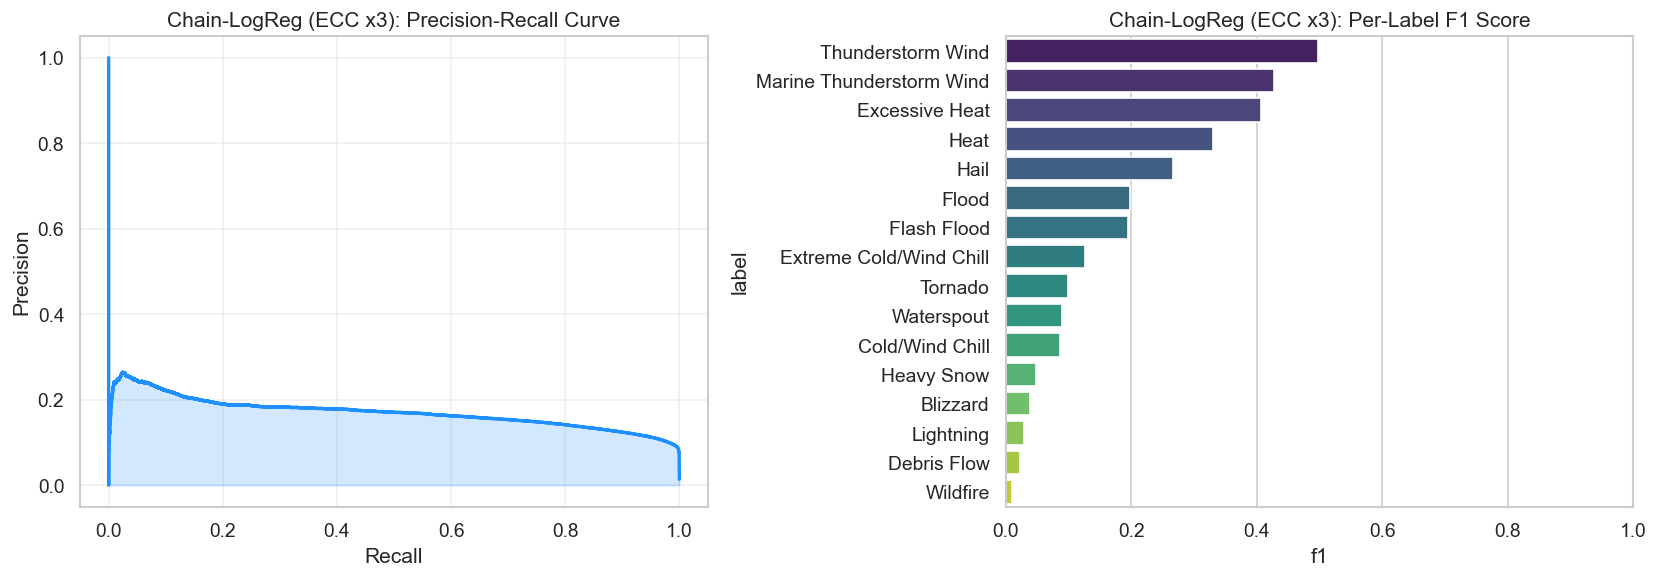

In [24]:
# --- Diagnostic Visualizations ---
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(14, 5))

# 1. Precision-Recall Curve (Weighted)
plt.subplot(1, 2, 1)
precision, recall, _ = precision_recall_curve(y_test.ravel(), y_prob_chain_lr.ravel())
plt.plot(recall, precision, color='dodgerblue', lw=2)
plt.fill_between(recall, precision, alpha=0.2, color='dodgerblue')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'{res["model"]}: Precision-Recall Curve')
plt.grid(True, alpha=0.3)

# 2. Per-Label F1 Score
plt.subplot(1, 2, 2)
df_f1 = per_label_f1(y_test, y_pred_chain_lr, target_names).sort_values('f1', ascending=False)
sns.barplot(data=df_f1, x='f1', y='label', palette='viridis')
plt.title(f'{res["model"]}: Per-Label F1 Score')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

**Model Insights: Ensemble Classifier Chain (ECC) (Logistic Regression)**

By ordering labels from most prevalent to least, this model attempts to use successful predictions of common disasters as additional evidence for rarer ones. Comparing this F1-per-label plot to the OVR baseline can highlight if chaining specifically improves performance on the 'harder' labels at the end of the chain.

### Method 3 — Classifier Chain (Random Forest)

Same chaining idea, but with a nonlinear base estimator.

In [29]:
method_id = 'chain_rf_ecc'
if method_id not in trained_methods:
    print('=' * 60)
    print('Method 3: ClassifierChain(RandomForest) - ECC Ensemble')
    print('=' * 60)
    if method_id not in trained_methods:
        t0_total = time.time()
        
        # ── Tune n_estimators / max_depth ──
        n_est_values = [50, 100, 200]
        depth_values = [5, 10, 15]
        best_rf_score, best_rf_params = -1, {'n_estimators': 100, 'max_depth': 10}
        for n_est, depth in iter_product(n_est_values, depth_values):
            t0 = time.time()
            curr_order = label_order
            chain = ClassifierChain(
                RandomForestClassifier(
                    n_estimators=n_est, max_depth=depth,
                    class_weight='balanced_subsample',
                    random_state=42, n_jobs=-1),
                order=curr_order, random_state=0)
            chain.fit(X_train_s, y_train)
            y_prob_v = chain.predict_proba(X_val_s)
            score = average_precision_score(y_val, y_prob_v, average='weighted')
            pass
            if score > best_rf_score:
                best_rf_score  = score
                best_rf_params = {'n_estimators': n_est, 'max_depth': depth}
        
        print(f'\n  ✓ Best: {best_rf_params}, val AUCPR={best_rf_score:.4f}')
        
        # ── Train final model — ensemble of 3 chains ──
        print(f'\nTraining final Chain-RF ensemble (3 chains) with {best_rf_params} ...')
        chains_rf = []
        for seed in [0, 1, 2]:
            curr_order = label_order if seed == 0 else 'random'
            chain = ClassifierChain(
                RandomForestClassifier(
                    n_estimators=best_rf_params['n_estimators'],
                    max_depth=best_rf_params['max_depth'],
                    class_weight='balanced_subsample',
                    random_state=42, n_jobs=-1),
                order=curr_order, random_state=seed
            )
            chain.fit(X_train_s, y_train)
            chains_rf.append(chain)
            print(f'  Chain {seed} done ({time.time()-t0_total:.0f}s elapsed)')
        
        y_prob_chain_rf     = np.mean([c.predict_proba(X_test_s) for c in chains_rf], axis=0)
        y_prob_chain_rf_val = np.mean([c.predict_proba(X_val_s)  for c in chains_rf], axis=0)
        y_pred_chain_rf     = (y_prob_chain_rf >= 0.5).astype(int)
        
        elapsed = time.time() - t0_total
        print(f'\nTotal time (tune + train): {elapsed:.1f}s\n')
        res = evaluate('Chain-RF (ECC x3)', y_test, y_pred_chain_rf, y_prob_chain_rf)
        save_method_checkpoint(method_id, res=res, y_pred_chain_rf=y_pred_chain_rf, chains_rf=chains_rf, y_prob_chain_rf=y_prob_chain_rf, y_prob_chain_rf_val=y_prob_chain_rf_val, best_rf_params=best_rf_params)
    
    save_method_checkpoint(method_id, res=res, y_pred_chain_rf=y_pred_chain_rf, chains_rf=chains_rf, y_prob_chain_rf=y_prob_chain_rf, y_prob_chain_rf_val=y_prob_chain_rf_val, best_rf_params=best_rf_params)
else:
    print(f"Method '{method_id}' already trained. Skipping training.")
    ckpt_path = MODEL_DIR / f"{method_id}_checkpoint.pkl"
    with open(ckpt_path, 'rb') as f:
        data = pickle.load(f)
    res = data['res']
    y_pred_chain_rf = data.get('y_pred_chain_rf', data.get('y_pred'))
    y_prob_chain_rf = data.get('y_prob_chain_rf', data.get('y_prob'))


Method 3: ClassifierChain(RandomForest) - ECC Ensemble


Python(45354) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.



  ✓ Best: {'n_estimators': 200, 'max_depth': 10}, val AUCPR=0.4226

Training final Chain-RF ensemble (3 chains) with {'n_estimators': 200, 'max_depth': 10} ...
  Chain 0 done (3846s elapsed)
  Chain 1 done (4278s elapsed)
  Chain 2 done (4671s elapsed)

Total time (tune + train): 4717.3s

--- Chain-RF (ECC x3) ---
  F1 (w/m/M): 0.3119 / 0.2452 / 0.1803
  AUCPR (w):  0.3866

✅ Saved chain_rf_ecc checkpoint to ../models/baseline/sklearn_models_no_cascade_prob/chain_rf_ecc_checkpoint.pkl

✅ Saved chain_rf_ecc checkpoint to ../models/baseline/sklearn_models_no_cascade_prob/chain_rf_ecc_checkpoint.pkl


/var/folders/md/l911vh8d02j9khvbpjpxvb4r0000gn/T/ipykernel_43872/1829797876.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_f1, x='f1', y='label', palette='viridis')


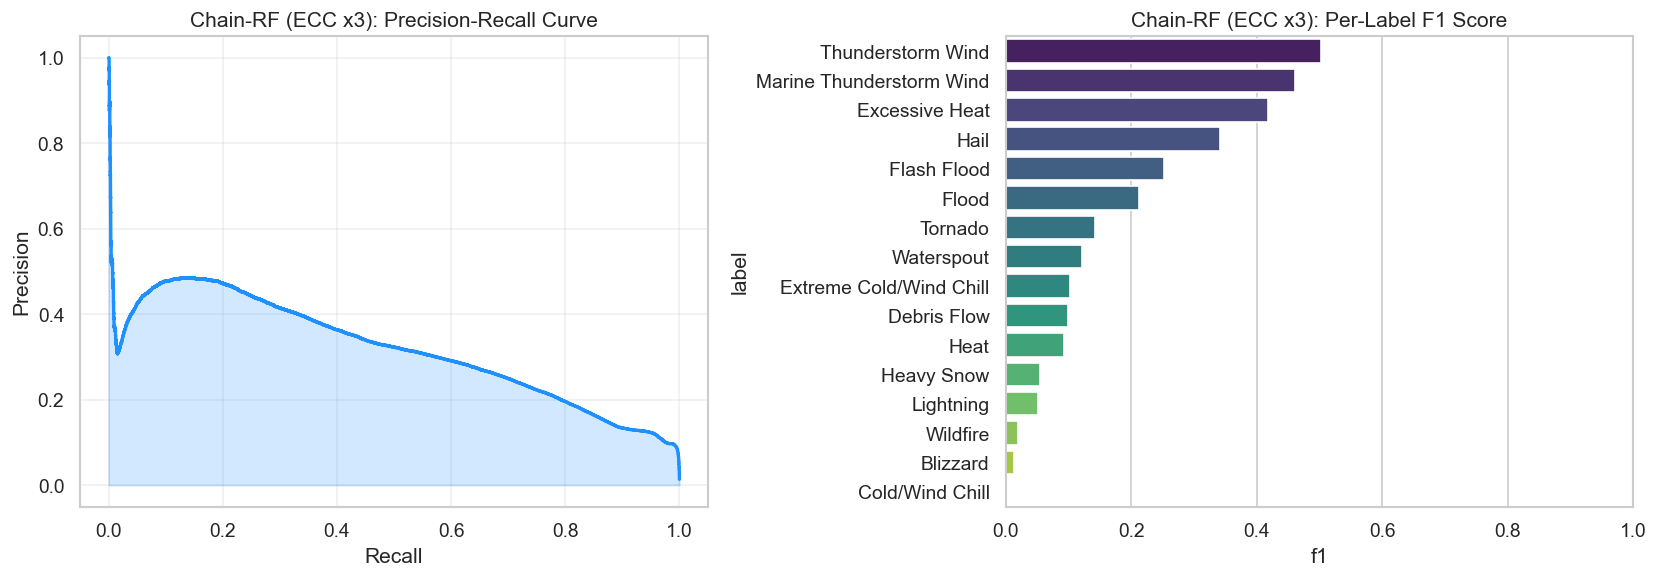

In [30]:
# --- Diagnostic Visualizations ---
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(14, 5))

# 1. Precision-Recall Curve (Weighted)
plt.subplot(1, 2, 1)
precision, recall, _ = precision_recall_curve(y_test.ravel(), y_prob_chain_rf.ravel())
plt.plot(recall, precision, color='dodgerblue', lw=2)
plt.fill_between(recall, precision, alpha=0.2, color='dodgerblue')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'{res["model"]}: Precision-Recall Curve')
plt.grid(True, alpha=0.3)

# 2. Per-Label F1 Score
plt.subplot(1, 2, 2)
df_f1 = per_label_f1(y_test, y_pred_chain_rf, target_names).sort_values('f1', ascending=False)
sns.barplot(data=df_f1, x='f1', y='label', palette='viridis')
plt.title(f'{res["model"]}: Per-Label F1 Score')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()


**Model Insights: Ensemble Classifier Chain (ECC) (Random Forest)**

This model combines the nonlinear capacity of Random Forests with label dependency modeling. It is typically the most powerful traditional baseline in this notebook. Higher precision at low recall levels in its PR-curve compared to the LogReg methods would indicate that the nonlinear features are better at identifying 'sure-bet' disaster relationships.

### Method 4 — MLP Neural Network

sklearn's `MLPClassifier` natively supports multilabel with sigmoid outputs.
Shared hidden layers, early stopping.

In [25]:
method_id = 'mlp'
if method_id not in trained_methods:
    print('=' * 60)
    print('Method 4: MLPClassifier')
    print('=' * 60)
    if method_id not in trained_methods:
        t0_total = time.time()
        
        # ── Tune architecture / learning rate ──
        arch_values = [(128, 64), (256, 128), (256, 128, 64)]
        lr_values   = [1e-3, 5e-4]
        best_mlp_score, best_mlp_params = -1, {'arch': (256, 128), 'lr': 1e-3}
        for arch, lr in iter_product(arch_values, lr_values):
            t0 = time.time()
            model = MLPClassifier(
                hidden_layer_sizes=arch, activation='relu', solver='adam',
                learning_rate_init=lr, max_iter=50, early_stopping=True,
                validation_fraction=0.1, n_iter_no_change=5,
                batch_size=512, random_state=42, verbose=False)
            score = val_macro_aucpr(model, X_train_s, y_train, X_val_s, y_val)
            pass
            if score > best_mlp_score:
                best_mlp_score  = score
                best_mlp_params = {'arch': arch, 'lr': lr}
        
        print(f'\n  ✓ Best: {best_mlp_params}, val AUCPR={best_mlp_score:.4f}')
        
        # ── Train final model (longer training) ──
        print(f'\nTraining final MLP with {best_mlp_params} ...')
        mlp = MLPClassifier(
            hidden_layer_sizes=best_mlp_params['arch'],
            activation='relu', solver='adam',
            learning_rate_init=best_mlp_params['lr'],
            max_iter=100, early_stopping=True,
            validation_fraction=0.1, n_iter_no_change=10,
            batch_size=512, random_state=42, verbose=False
        )
        mlp.fit(X_train_s, y_train)
        
        y_pred_mlp     = mlp.predict(X_test_s)
        y_prob_mlp     = mlp.predict_proba(X_test_s)
        y_prob_mlp_val = mlp.predict_proba(X_val_s)
        
        elapsed = time.time() - t0_total
        print(f'\nTotal time (tune + train): {elapsed:.1f}s  '
              f'(stopped at iteration {mlp.n_iter_})\n')
        mlp_label = f'MLP {best_mlp_params["arch"]}'
        res = evaluate(mlp_label, y_test, y_pred_mlp, y_prob_mlp)
        save_method_checkpoint(method_id, res=res, y_pred_mlp=y_pred_mlp, mlp=mlp, y_prob_mlp=y_prob_mlp, y_prob_mlp_val=y_prob_mlp_val, best_mlp_params=best_mlp_params)
    save_method_checkpoint(method_id, res=res, y_pred_mlp=y_pred_mlp, mlp=mlp, y_prob_mlp=y_prob_mlp, y_prob_mlp_val=y_prob_mlp_val, best_mlp_params=best_mlp_params)
else:
    print(f"Method '{method_id}' already trained. Skipping training.")
    ckpt_path = MODEL_DIR / f"{method_id}_checkpoint.pkl"
    with open(ckpt_path, 'rb') as f:
        data = pickle.load(f)
    res = data['res']
    y_pred_mlp = data.get('y_pred_mlp', data.get('y_pred'))
    y_prob_mlp = data.get('y_prob_mlp', data.get('y_prob'))
    mlp = data.get('mlp')


Method 4: MLPClassifier

  ✓ Best: {'arch': (128, 64), 'lr': 0.0005}, val AUCPR=0.3923

Training final MLP with {'arch': (128, 64), 'lr': 0.0005} ...

Total time (tune + train): 1301.0s  (stopped at iteration 61)

--- MLP (128, 64) ---
  F1 (w/m/M): 0.2512 / 0.2778 / 0.1686
  AUCPR (w):  0.3632

✅ Saved mlp checkpoint to ../models/baseline/sklearn_models_no_cascade_prob/mlp_checkpoint.pkl

✅ Saved mlp checkpoint to ../models/baseline/sklearn_models_no_cascade_prob/mlp_checkpoint.pkl


/var/folders/md/l911vh8d02j9khvbpjpxvb4r0000gn/T/ipykernel_43872/3809579591.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_f1, x='f1', y='label', palette='viridis')


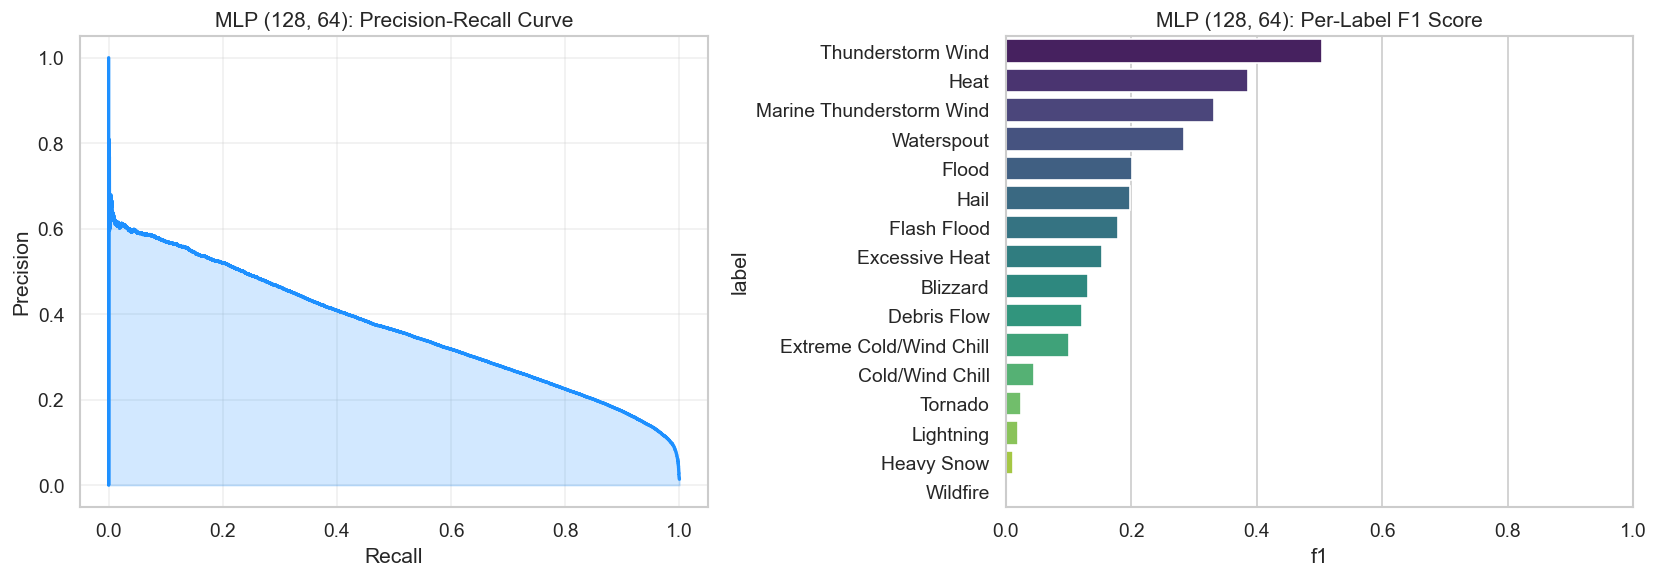

In [26]:
# --- Diagnostic Visualizations ---
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(14, 5))

# 1. Precision-Recall Curve (Weighted)
plt.subplot(1, 2, 1)
precision, recall, _ = precision_recall_curve(y_test.ravel(), y_prob_mlp.ravel())
plt.plot(recall, precision, color='dodgerblue', lw=2)
plt.fill_between(recall, precision, alpha=0.2, color='dodgerblue')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'{res["model"]}: Precision-Recall Curve')
plt.grid(True, alpha=0.3)

# 2. Per-Label F1 Score
plt.subplot(1, 2, 2)
df_f1 = per_label_f1(y_test, y_pred_mlp, target_names).sort_values('f1', ascending=False)
sns.barplot(data=df_f1, x='f1', y='label', palette='viridis')
plt.title(f'{res["model"]}: Per-Label F1 Score')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()


**Model Insights: MLP Neural Network**

The MLP learns joint representations across all labels through shared hidden layers. While natively handling multilabel data, its performance can suffer if imbalance is not addressed. A 'flat' F1 distribution here suggests the network might be ignoring rare labels in favor of common ones (majority class bias).

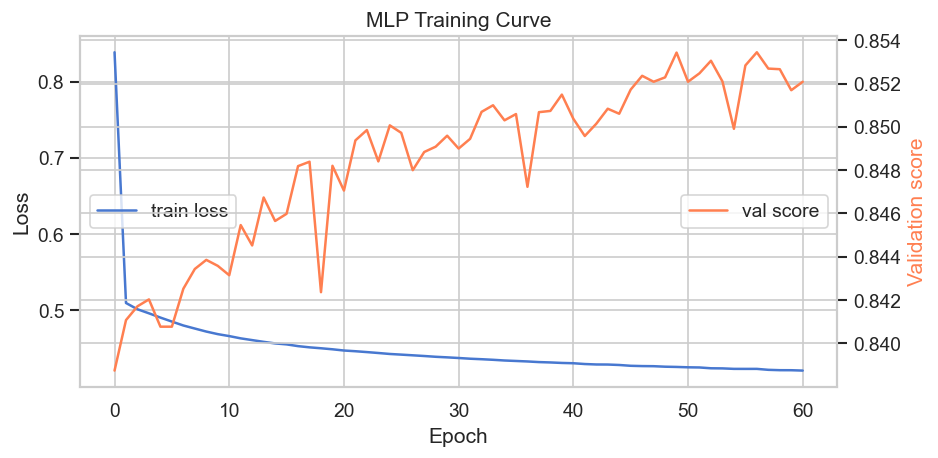

In [27]:
# --- MLP training curve ---
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(mlp.loss_curve_, label='train loss')
if hasattr(mlp, 'validation_scores_') and mlp.validation_scores_ is not None:
    ax2 = ax.twinx()
    ax2.plot(mlp.validation_scores_, color='coral', label='val score')
    ax2.set_ylabel('Validation score', color='coral')
    ax2.legend(loc='center right')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('MLP Training Curve')
ax.legend(loc='center left')
plt.tight_layout()
plt.show()

## 5. Per-label Threshold Tuning
All models above use default 0.5 threshold.  
Tune per-label thresholds on the **validation set**, then evaluate on the **test set**.

In [33]:
def tune_thresholds(y_true, y_prob, target_names):
    """Find per-label threshold that maximises F1 on the given set."""
    n_labels = y_true.shape[1]
    thresholds = np.full(n_labels, 0.5)
    for i in range(n_labels):
        if y_true[:, i].sum() == 0:
            continue
        precs, recs, thresh = precision_recall_curve(y_true[:, i], y_prob[:, i])
        f1s = 2 * precs * recs / (precs + recs + 1e-8)
        best = np.argmax(f1s)
        if best < len(thresh):
            thresholds[i] = thresh[best]
    return thresholds

# Tune thresholds on VALIDATION set, then evaluate on TEST set
mlp_name = f'MLP {best_mlp_params["arch"]}'

prob_models_val = {
    'OVR-LogReg':        y_prob_ovr_val,
    'Chain-LogReg (x3)': y_prob_chain_lr_val,
    'Chain-RF (x3)':     y_prob_chain_rf_val,
    mlp_name:            y_prob_mlp_val,
}

prob_models_test = {
    'OVR-LogReg':        y_prob_ovr,
    'Chain-LogReg (x3)': y_prob_chain_lr,
    'Chain-RF (x3)':     y_prob_chain_rf,
    mlp_name:            y_prob_mlp,
}

tuned_results = []
for name in prob_models_val:
    # Tune on val
    threshs = tune_thresholds(y_val, prob_models_val[name], target_names)
    # Apply to test
    y_pred_t = (prob_models_test[name] >= threshs).astype(int)
    res = evaluate(f'{name} (tuned)', y_test, y_pred_t, prob_models_test[name])
    tuned_results.append(res)
    all_preds[f'{name} (tuned)'] = y_pred_t
    print(f'  Thresholds: min={threshs.min():.3f}, max={threshs.max():.3f}, mean={threshs.mean():.3f}\n')


--- OVR-LogReg (tuned) ---
  F1 (w/m/M): 0.3550 / 0.3208 / 0.2329
  AUCPR (w):  0.3038
  Thresholds: min=0.791, max=0.997, mean=0.927

--- Chain-LogReg (x3) (tuned) ---
  F1 (w/m/M): 0.3527 / 0.3249 / 0.2336
  AUCPR (w):  0.3028
  Thresholds: min=0.861, max=0.997, mean=0.952

--- Chain-RF (x3) (tuned) ---
  F1 (w/m/M): 0.1410 / 0.1607 / 0.0860
  AUCPR (w):  0.3866
  Thresholds: min=0.658, max=0.983, mean=0.865

--- MLP (128, 64) (tuned) ---
  F1 (w/m/M): 0.3919 / 0.3985 / 0.2755
  AUCPR (w):  0.3632
  Thresholds: min=0.007, max=0.465, mean=0.174



In [35]:
# Final results aggregated in all_results and all_preds sorted by F1macro\n
all_results = sorted(all_results, key=lambda x: -x['f1_macro'])

## 6. Compare All Models

In [36]:
compare_df = pd.DataFrame(all_results + tuned_results).set_index('model')
compare_df.sort_values('f1_macro', ascending=False).style.format('{:.4f}').background_gradient(
    cmap='RdYlGn', subset=['f1_macro', 'f1_micro', 'f1_weighted', 'aucpr_weighted']
)


,f1_macro,f1_micro,f1_weighted,precision_weighted,recall_weighted,precision_macro,recall_macro,hamming_loss,subset_accuracy,aucpr_weighted
model,,,,,,,,,,
"MLP (128, 64) (tuned)",0.2755,0.3985,0.3919,0.3662,0.4522,0.2502,0.3639,0.0188,0.7471,0.3632
Chain-LogReg (x3) (tuned),0.2336,0.3249,0.3527,0.2704,0.5389,0.1774,0.5061,0.0308,0.6237,0.3028
OVR-LogReg (tuned),0.2329,0.3208,0.3550,0.2662,0.5755,0.1727,0.5440,0.0335,0.5932,0.3038
OVR-LogReg,0.1814,0.1818,0.2925,0.1795,0.9796,0.1085,0.9636,0.1214,0.1464,0.3038
Chain-RF (x3) (tuned),0.0860,0.1607,0.1410,0.4783,0.1007,0.2258,0.0946,0.0145,0.8030,0.3866


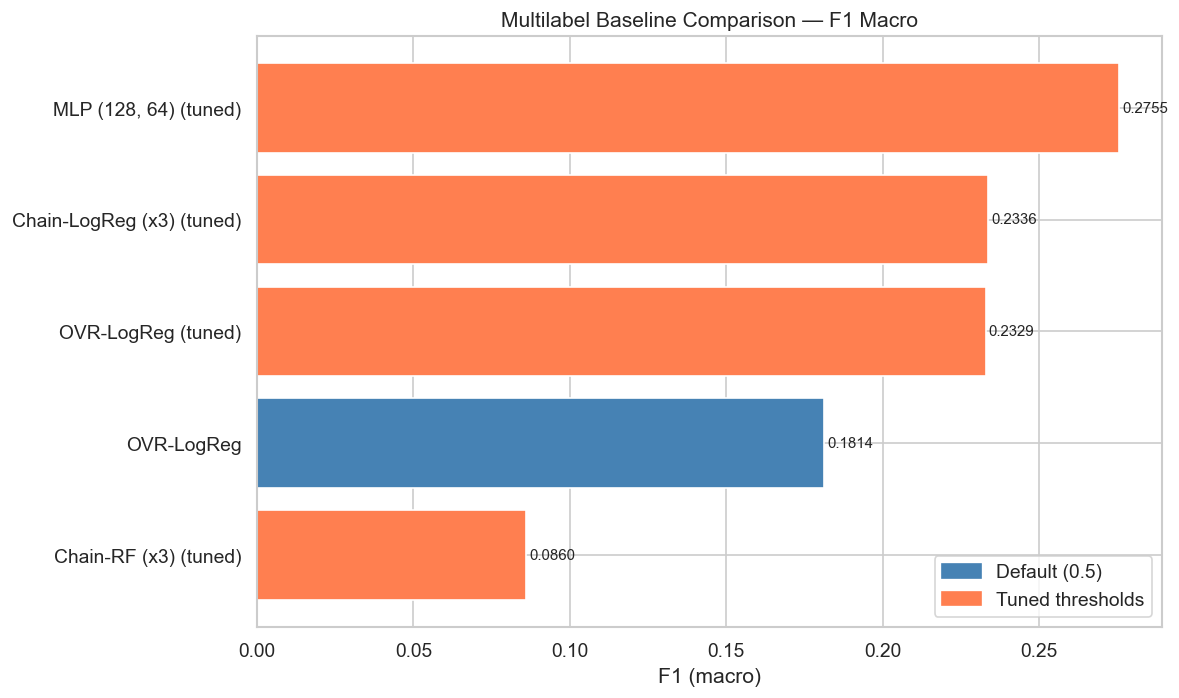

In [37]:
# --- Bar chart: F1 macro comparison ---
plot_df = compare_df.reset_index().sort_values('f1_macro', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['coral' if '(tuned)' in m else 'steelblue' for m in plot_df['model']]
ax.barh(plot_df['model'], plot_df['f1_macro'], color=colors)
ax.set_xlabel('F1 (macro)')
ax.set_title('Multilabel Baseline Comparison — F1 Macro')

for i, (val, model) in enumerate(zip(plot_df['f1_macro'], plot_df['model'])):
    ax.text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=9)

ax.legend(handles=[
    plt.Rectangle((0,0),1,1, color='steelblue', label='Default (0.5)'),
    plt.Rectangle((0,0),1,1, color='coral', label='Tuned thresholds'),
], loc='lower right')
plt.tight_layout()
plt.show()

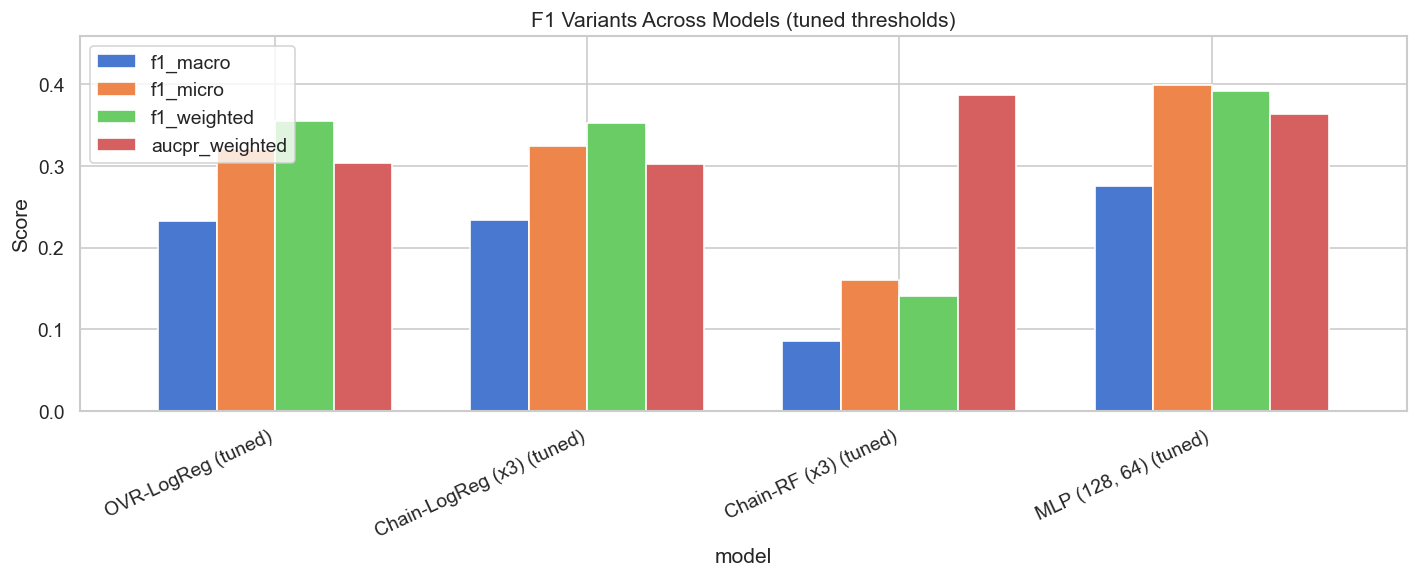

In [38]:
# --- Grouped bar: F1 macro / micro / weighted ---
metrics_to_plot = ['f1_macro', 'f1_micro', 'f1_weighted', 'aucpr_weighted']
# Use only tuned versions for cleaner comparison
tuned_df = pd.DataFrame(tuned_results).set_index('model')[metrics_to_plot]

fig, ax = plt.subplots(figsize=(12, 5))
tuned_df.plot(kind='bar', ax=ax, width=0.75)
ax.set_ylabel('Score')
ax.set_title('F1 Variants Across Models (tuned thresholds)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right')
ax.legend(loc='upper left')
ax.set_ylim(0, max(tuned_df.max()) * 1.15)
plt.tight_layout()
plt.show()


## 7. Per-label Breakdown (Best Model)

In [39]:
# Find best tuned model
best_tuned = max(tuned_results, key=lambda r: r['f1_macro'])
best_name  = best_tuned['model']
best_pred  = all_preds[best_name]

print(f'Best model: {best_name}  (F1 macro = {best_tuned["f1_macro"]:.4f})\n')

plf = per_label_f1(y_test, best_pred, target_names)
plf.sort_values('f1', ascending=False).style.format({
    'support': '{:,}', 'f1': '{:.3f}', 'precision': '{:.3f}', 'recall': '{:.3f}'
}).bar(subset=['f1'], color='#5fba7d')

Best model: MLP (128, 64) (tuned)  (F1 macro = 0.2755)



,label,support,f1,precision,recall
12,Thunderstorm Wind,"9,688",0.603,0.476,0.823
11,Marine Thunderstorm Wind,169,0.520,0.407,0.722
8,Heat,"2,406",0.428,0.410,0.448
7,Hail,"9,749",0.408,0.435,0.384
3,Excessive Heat,"3,070",0.394,0.344,0.461
14,Waterspout,286,0.306,0.399,0.248
6,Flood,"1,869",0.294,0.206,0.515
5,Flash Flood,"9,973",0.289,0.325,0.261
13,Tornado,"3,125",0.216,0.194,0.243
1,Cold/Wind Chill,206,0.203,0.150,0.316


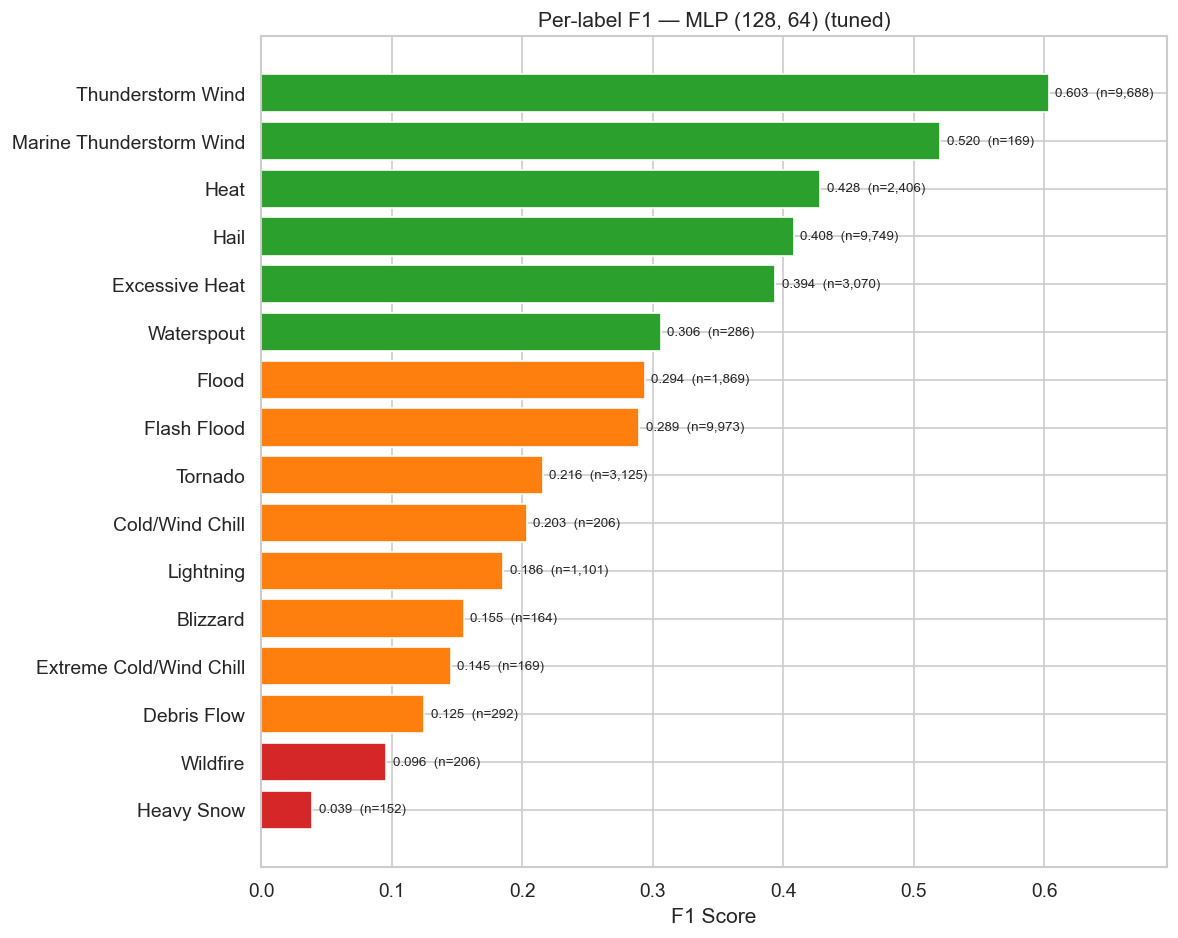

In [40]:
# --- Per-label F1: best sklearn model ---
plf_sorted = plf.sort_values('f1', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#2ca02c' if f >= 0.3 else '#ff7f0e' if f >= 0.1 else '#d62728' for f in plf_sorted['f1']]
ax.barh(plf_sorted['label'], plf_sorted['f1'], color=colors)
ax.set_xlabel('F1 Score')
ax.set_title(f'Per-label F1 — {best_name}')
ax.set_xlim(0, max(plf_sorted['f1'].max() * 1.15, 0.5))

for i, (f1, sup) in enumerate(zip(plf_sorted['f1'], plf_sorted['support'])):
    ax.text(f1 + 0.005, i, f'{f1:.3f}  (n={sup:,})', va='center', fontsize=8)

plt.tight_layout()
plt.show()

## 8. Does Chaining Actually Help?

Compare OVR (independent labels) vs ClassifierChain (dependent labels)  
using the **same base estimator** (LogisticRegression) to isolate the effect  
of label dependency modeling.

In [42]:
all_preds

{'OVR-LogReg': array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 1, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 1, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 1]]),
 'Chain-LogReg (ECC x3)': array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 1, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 1, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 1]]),
 'OVR-LogReg (tuned)': array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]]),
 'Chain-LogReg (x3) (tuned)': array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]]),
 'Chain-RF (x3) (tuned)': array([[0, 0, 0, ..., 0, 0, 0],


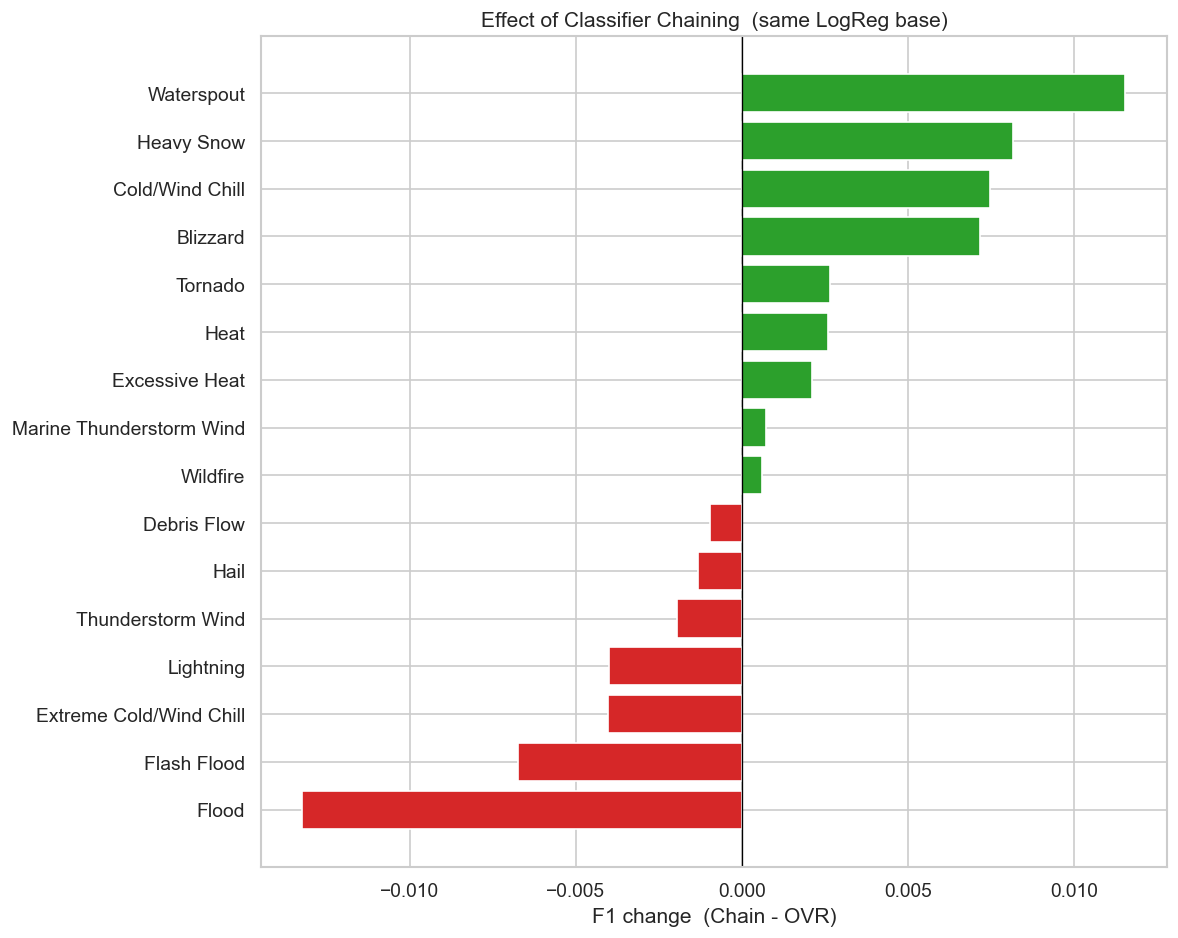

Labels improved by chaining: 9/16
Labels worsened by chaining: 7/16
Mean delta F1: +0.0007


In [43]:
ovr_plf   = per_label_f1(y_test, all_preds.get('OVR-LogReg (tuned)',   all_preds['OVR-LogReg']),       target_names)
chain_plf = per_label_f1(y_test, all_preds.get('Chain-LogReg (x3) (tuned)', all_preds['Chain-LogReg (ECC x3)']), target_names)

cmp = ovr_plf[['label', 'f1']].rename(columns={'f1': 'f1_OVR'}).merge(
    chain_plf[['label', 'f1']].rename(columns={'f1': 'f1_Chain'}),
    on='label'
)
cmp['delta'] = cmp['f1_Chain'] - cmp['f1_OVR']
cmp = cmp.sort_values('delta', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#2ca02c' if d > 0 else '#d62728' for d in cmp['delta']]
ax.barh(cmp['label'], cmp['delta'], color=colors)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('F1 change  (Chain - OVR)')
ax.set_title('Effect of Classifier Chaining  (same LogReg base)')
plt.tight_layout()
plt.show()

improved  = (cmp['delta'] > 0).sum()
worsened  = (cmp['delta'] < 0).sum()
print(f'Labels improved by chaining: {improved}/{len(cmp)}')
print(f'Labels worsened by chaining: {worsened}/{len(cmp)}')
print(f'Mean delta F1: {cmp["delta"].mean():+.4f}')

## 9. Cross-Method Comparison

Comparing performance across different modeling strategies.

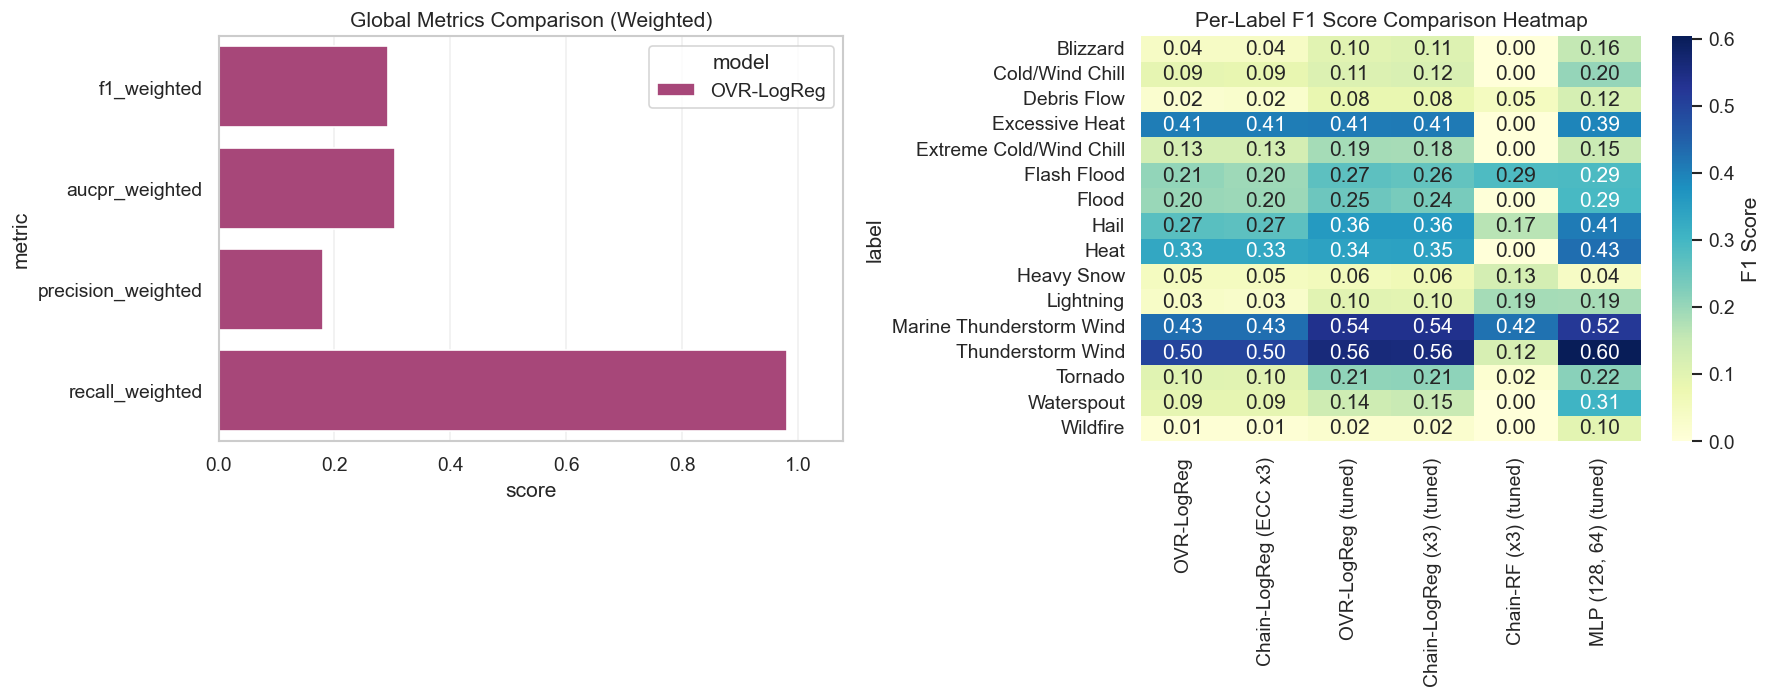

In [44]:
# --- Global Performance Comparison ---
df_all = pd.DataFrame(all_results)
metrics = ['f1_weighted', 'aucpr_weighted', 'precision_weighted', 'recall_weighted']

plt.figure(figsize=(15, 6))

# 1. Grouped Bar Chart of Main Metrics
plt.subplot(1, 2, 1)
df_melt = df_all.melt(id_vars='model', value_vars=metrics, var_name='metric', value_name='score')
sns.barplot(data=df_melt, x='score', y='metric', hue='model', palette='magma')
plt.title('Global Metrics Comparison (Weighted)')
plt.xlim(0, max(df_all[metrics].values.max() * 1.1, 0.5))
plt.grid(True, axis='x', alpha=0.3)

# 2. Performance Heatmap (Labels vs Models)
plt.subplot(1, 2, 2)
label_metrics = []
for m_name in all_preds.keys():
    y_p = all_preds[m_name]
    f1s = per_label_f1(y_test, y_p, target_names)[['label', 'f1']]
    f1s.columns = ['label', m_name]
    label_metrics.append(f1s.set_index('label'))

df_heat = pd.concat(label_metrics, axis=1)
sns.heatmap(df_heat, annot=True, fmt='.2f', cmap='YlGnBu', cbar_kws={'label': 'F1 Score'})
plt.title('Per-Label F1 Score Comparison Heatmap')
plt.tight_layout()
plt.show()


**Global Comparison Insights**

The comparison heatmap is the most informative visualization for identifying label dependencies. If a label (e.g., *Flash Flood*) has a significantly higher F1 score in the **Classifier Chain** models than in **OneVsRest**, it strongly suggests that knowing about previous events (like *Thunderstorm Wind*) is highly predictive of that disaster. The global bar chart summarizes which overall approach (Linear, Nonlinear, or Neural) is best suited for this specific disaster prediction task.

## 10. Summary

In [45]:
print('╔════════════════════════════════════════════════════════════════════════╗')

print('║                      Multilabel Baseline Summary                       ║')

print('╠════════════════════════════════════════════════════════════════════════╣')


best_overall = max(all_results + (tuned_results if 'tuned_results' in globals() else []), key=lambda x: x['f1_macro'])
for r in sorted(all_results + (tuned_results if 'tuned_results' in globals() else []), key=lambda x: -x['f1_macro']):
    tag = '★' if r['model'] == best_overall['model'] else ' '
    print(f'║ {tag} {r["model"]:30s}  F1w={r["f1_weighted"]: .4f}  '\
          f'APw={r.get("aucpr_weighted", 0):.4f}  F1m={r["f1_macro"]: .4f} ║')

print('╚════════════════════════════════════════════════════════════════════════╝')

print(f'\n★ = best overall')
print(f'\nPipeline:')
print(f'  • Consistent 16-label dataset (0.05% prevalence threshold) → {len(target_names)} labels kept')
print(f'  • Train/Val/Test split: {X_train.shape[0]:,} / {X_val.shape[0]:,} / {X_test.shape[0]:,}')
print(f'  • Training data subsampled for speed (all positives kept)')
print(f'  • HP tuning on validation set BEFORE training (OVR-LR, Chain-RF, MLP)')
print(f'  • Threshold tuning on validation set (not test)')
print(f'\nKey takeaways:')
print(f'  • OVR LogReg provides the simplest linear baseline')
print(f'  • ClassifierChain can capture label dependencies (e.g. Flash Flood → Debris Flow)')
print(f'  • MLP provides a neural baseline with shared feature representation')
print(f'  • HP tuning + threshold tuning on val set prevents overfitting to test')
print(f'  • Compare these against XGBoost Binary Relevance from notebook 02')

╔════════════════════════════════════════════════════════════════════════╗
║                      Multilabel Baseline Summary                       ║
╠════════════════════════════════════════════════════════════════════════╣
║ ★ MLP (128, 64) (tuned)           F1w= 0.3919  APw=0.3632  F1m= 0.2755 ║
║   Chain-LogReg (x3) (tuned)       F1w= 0.3527  APw=0.3028  F1m= 0.2336 ║
║   OVR-LogReg (tuned)              F1w= 0.3550  APw=0.3038  F1m= 0.2329 ║
║   OVR-LogReg                      F1w= 0.2925  APw=0.3038  F1m= 0.1814 ║
║   Chain-RF (x3) (tuned)           F1w= 0.1410  APw=0.3866  F1m= 0.0860 ║
╚════════════════════════════════════════════════════════════════════════╝

★ = best overall

Pipeline:
  • Consistent 16-label dataset (0.05% prevalence threshold) → 16 labels kept
  • Train/Val/Test split: 690,714 / 77,396 / 193,489
  • Training data subsampled for speed (all positives kept)
  • HP tuning on validation set BEFORE training (OVR-LR, Chain-RF, MLP)
  • Threshold tuning on validatio